In [1]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms

from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

In [2]:
# Loading the dataset

data_transform = transforms.Compose([transforms.ToTensor()])

train_data = datasets.MNIST(root = './data', train = True, download = True, transform = data_transform)
test_data = datasets.MNIST(root = './data', train = False, download = True, transform = data_transform)

100%|██████████| 9.91M/9.91M [00:00<00:00, 62.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 1.80MB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 15.5MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.57MB/s]


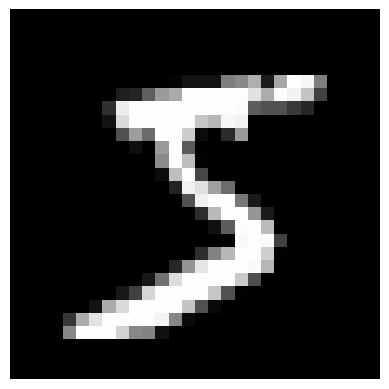

This image corresponds to the label:  5
Number of images in training: 60000, & testing dataset: 10000


In [3]:
# Vewing the dataset

plt.imshow(train_data[0][0].view(28, 28), cmap = 'gray')
plt.axis('off')
plt.show()
print('This image corresponds to the label: ', train_data[0][1])

print(f'Number of images in training: {len(train_data)}, & testing dataset: {len(test_data)}')

In [4]:
# Creating batches

Batch_Size = 128

train_loader = DataLoader(train_data, batch_size = Batch_Size, shuffle = True)
test_loader = DataLoader(test_data, batch_size = Batch_Size, shuffle = True)

In [5]:
# VAE class

class VAE(nn.Module):

  def __init__(self, hidden_dim = 256, latent_dim = 32):
    super().__init__()

    # Encoder
    self.fc1 = nn.Linear(784, hidden_dim)
    self.mu = nn.Linear(hidden_dim, latent_dim)
    self.logvar = nn.Linear(hidden_dim, latent_dim)


    # Decoder
    self.fc2 = nn.Linear(latent_dim, hidden_dim)
    self.fc3 = nn.Linear(hidden_dim, 784)

    self.relu = nn.ReLU()
    self.sigmoid = nn.Sigmoid()


  # Encode
  def encode(self, x):
    h = self.relu(self.fc1(x))
    mu = self.mu(h)
    logvar = self.logvar(h)
    return mu, logvar

  # Reparameterize
  def reparameterize(self, mu, logvar):
    std = torch.exp(0.5*logvar)                   # Standard deviation is sigma, while sigma square is the variance
    eps = torch.rand_like(std)
    z = mu + eps*std
    return z

  # Decode
  def decode(self, z):
    a = self.relu(self.fc2(z))
    out = self.sigmoid(self.fc3(a))
    return out

  # Forward Pass
  def forward(self, x):
    mu, logvar = self.encode(x)
    z = self.reparameterize(mu, logvar)
    x_reconstructed = self.decode(z)
    return x_reconstructed, mu, logvar

In [6]:
# Defining the Loss

def loss_fuc(x, x_reconstructed, mu, logvar):

  recon_loss = nn.functional.mse_loss(x_reconstructed, x, reduction='sum')

  std = torch.exp(0.5*logvar)
  kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())

  total_loss = recon_loss + kl_loss
  return total_loss

In [7]:
# Initializing the model, and defining optimizer

model = VAE()

optimizer = optim.Adam(model.parameters(), lr = 1e-3)

In [11]:
# Training the model

Epochs = 10

model.train()

for epoch in range(Epochs):
  total_epoch_loss = 0                        # Reset total_epoch_loss for each epoch

  for x, _ in train_loader:
    x = x.view(-1, 784)

    optimizer.zero_grad()
    x_recon, mu, logvar = model.forward(x)

    loss = loss_fuc(x, x_recon, mu, logvar)
    loss.backward()
    optimizer.step()

    total_epoch_loss += loss.item()            # Accumulate batch loss

  # Calculate average epoch loss
  epoch_avg_loss = total_epoch_loss / len(train_loader.dataset)

  print(f'Epoch [{epoch + 1}/{Epochs}]: Loss: {epoch_avg_loss}')

Epoch [1/10]: Loss: 18.68002493082682
Epoch [2/10]: Loss: 18.25148514404297
Epoch [3/10]: Loss: 17.898234814453126
Epoch [4/10]: Loss: 17.609391192626955
Epoch [5/10]: Loss: 17.36237436319987
Epoch [6/10]: Loss: 17.152788647460937
Epoch [7/10]: Loss: 16.99226923014323
Epoch [8/10]: Loss: 16.845380114746092
Epoch [9/10]: Loss: 16.71806075846354
Epoch [10/10]: Loss: 16.596076076253254


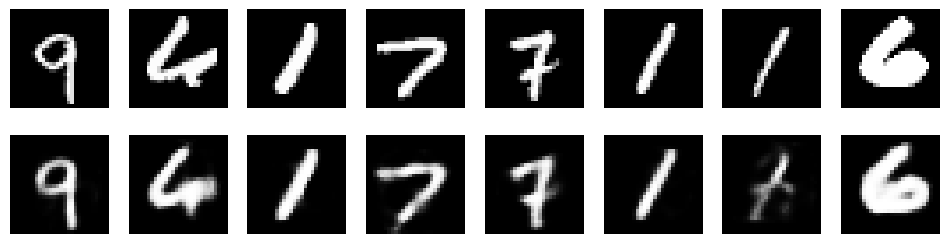

In [12]:
# Plotting Original vs Reconstructed images from Testing data

model.eval()

with torch.no_grad():

  x, _ = next(iter(test_loader))
  x = x.view(-1, 784)
  x_recon = model.forward(x)

  n = 8                                           # n --> Number of images to plot
  plt.figure(figsize = (12, 3))

  for i in range(n):

    # Original image
    plt.subplot(2, n, i+1)
    plt.imshow(x[i].view(28, 28), cmap = 'gray')
    plt.axis('off')

    # Reconstructed image
    plt.subplot(2, n, i+1+n)
    plt.imshow(x_recon[0][i].view(28, 28), cmap = 'gray') # Corrected indexing
    plt.axis('off')

  plt.show()

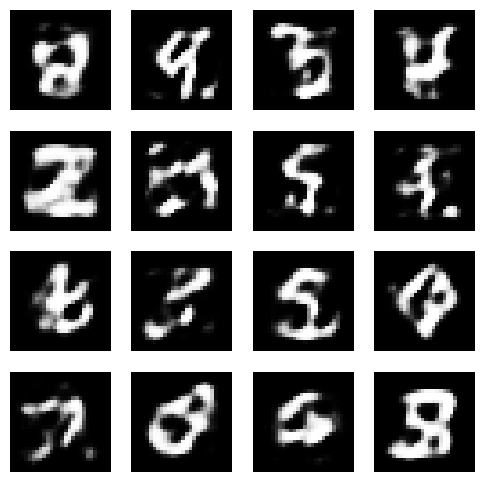

In [14]:
# Checking the Decoder of the model

with torch.no_grad():

  latent_dim = 32
  z = torch.randn(16, latent_dim)
  x_recon = model.decode(z)                # Only running the decoder for these random 16 vectors, in the latent space

  plt.figure(figsize = (6, 6))
  for i in range(16):
    plt.subplot(4, 4, i+1)
    plt.imshow(x_recon[i].view(28, 28), cmap = 'gray')
    plt.axis('off')
  plt.show()